Number of points in Richness :  (1055, 57)
Number of points in Diversity :  (794, 57)


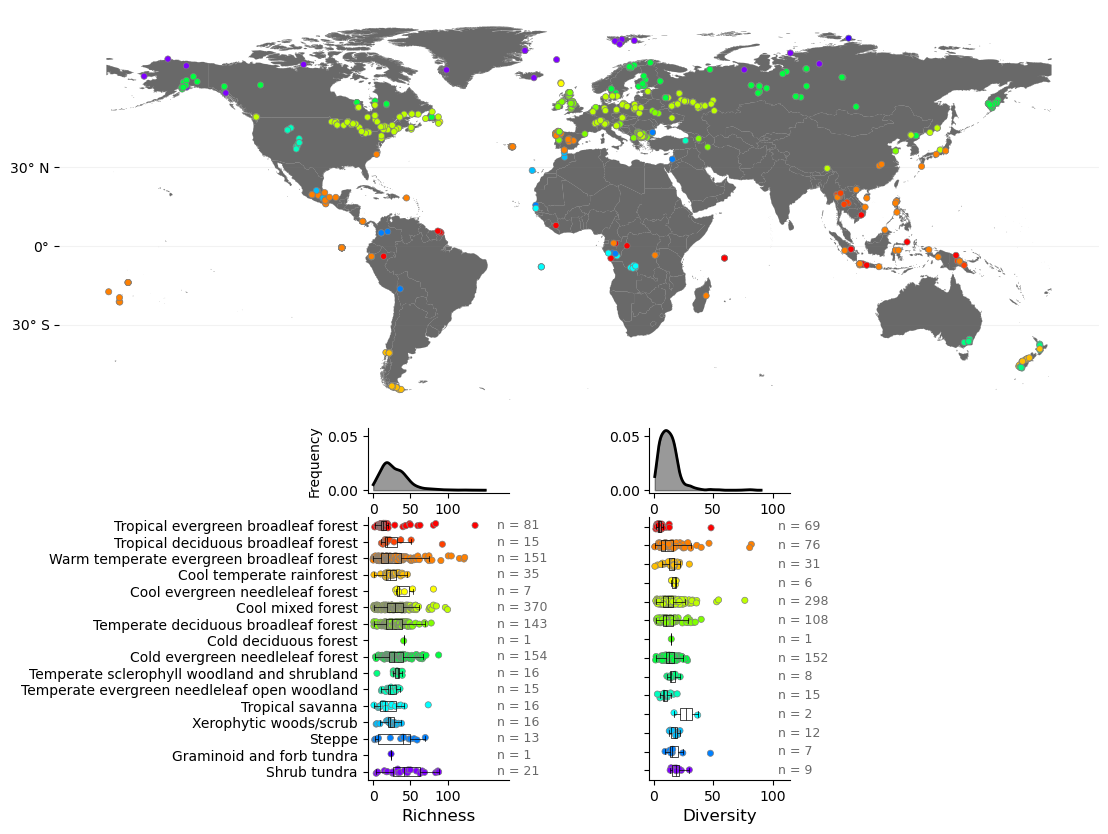

In [5]:
# Import libraries
import rasterio
import pandas as pd
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from scipy.interpolate import CubicSpline

# Open files
pathToFile = r'G:\Amibatec\Updated2025\TA_Richness_GEEformated_Covariables_Sampled.csv'
rawData = pd.read_csv(pathToFile,sep=",",encoding= 'unicode_escape')
Data_Richness = pd.DataFrame(rawData)
print('Number of points in Richness : ', Data_Richness.shape)

pathToFile = r'G:\Amibatec\Updated2025\TA_Diversity_GEEformated_Covariables_Sampled.csv'
rawData = pd.read_csv(pathToFile,sep=",",encoding= 'unicode_escape')
Data_Diversity = pd.DataFrame(rawData)
print('Number of points in Diversity : ', Data_Diversity.shape)

world_boundaries_shp = r"G:\Amibatec\Updated2025\world-administrative-boundaries.shp"
allpts_shp = r"G:\Amibatec\Updated2025\Pts_All_ForFig1shp.shp"

# Configure the figure
fig = plt.figure(figsize=(20, 10))

gs = gridspec.GridSpec(3, 6, figure=fig,height_ratios = [3, 0.5, 2],wspace=1, hspace=0.1)
ax_mapRichness = fig.add_subplot(gs[0, 0:8])
ax_profileRichness = fig.add_subplot(gs[2, 2:3])
ax_profileDiversity = fig.add_subplot(gs[2, 3:4])
ax_histRichness = fig.add_subplot(gs[1, 2:3],sharex=ax_profileRichness)
ax_histDiversity = fig.add_subplot(gs[1, 3:4],sharex=ax_profileDiversity,sharey=ax_histRichness)

profile_axes = [ax_profileRichness, ax_profileDiversity]
hist_axes = [ax_histRichness, ax_histDiversity]
maps_axes = [ax_mapRichness]

for ax in maps_axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

for ax in hist_axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

for ax in profile_axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

# Affichage de la carte
world = gpd.read_file(world_boundaries_shp)
world.plot(ax= ax_mapRichness, color='dimgrey', edgecolor='dimgrey',linewidth=0.1, zorder=0)

# Affichage des points sur la carte
# Dictionnaire de mappage pour la reclassification
BIOME_RECLASS_MAP = {'1': 'Tropical evergreen broadleaf forest', # tropical evergreen broadleaf forest
                     '2': 'Tropical evergreen broadleaf forest', # tropical semi-evergreen broadleaf forest
                     '3': 'Tropical deciduous broadleaf forest', # tropical deciduous broadleaf forest and woodland
                     '4': 'Warm temperate evergreen broadleaf forest', # warm-temperate evergreen broadleaf and mixed forest
                     '7': 'Cool temperate rainforest', # cool-temperate rainforest
                     '8': 'Cool evergreen needleleaf forest', # cool evergreen needleleaf forest
                     '9': 'Cool mixed forest', # cool mixed forest
                     '13': 'Temperate deciduous broadleaf forest', # temperate deciduous broadleaf forest
                     '14': 'Cold deciduous forest', # cold deciduous forest
                     '15': 'Cold evergreen needleleaf forest', # cold evergreen needleleaf forest
                     '16': 'Temperate sclerophyll woodland and shrubland', # temperate sclerophyll woodland and shrubland
                     '17': 'Temperate evergreen needleleaf open woodland', # temperate evergreen needleleaf open woodland
                     '18': 'Tropical savanna', # tropical savanna
                     '20': 'Xerophytic woods/scrub', # xerophytic woods/scrub
                     '22': 'Steppe', # steppe
                     '27': 'Desert', # desert
                     '28': 'Graminoid and forb tundra', # graminoid and forb tundra
                     '30': 'Shrub tundra', # erect dwarf shrub tundra
                     '31': 'Shrub tundra', # low and high shrub tundra
                     '32': 'Shrub tundra', # prostrate dwarf shrub tundra
                     'Unknown': 'F. Inconnu'}

# Nouvelle palette de couleurs simplifiée pour les NOUVEAUX groupes (6 couleurs)
RECLASSIFIED_COLORS = {
    'Tropical evergreen broadleaf forest': '#FF0000',
    'Tropical deciduous broadleaf forest': '#FF4000',
    'Warm temperate evergreen broadleaf forest': '#FF8000',
    'Cool temperate rainforest':'#FFBF00',
    'Cool evergreen needleleaf forest': '#FFFF00',
    'Cool mixed forest':'#BFFF00',
    'Temperate deciduous broadleaf forest': '#80FF00',
    'Cold deciduous forest': '#40FF00',
    'Cold evergreen needleleaf forest':'#00FF40',
    'Temperate sclerophyll woodland and shrubland': '#00FF80',
    'Temperate evergreen needleleaf open woodland': '#00FFBF',
    'Tropical savanna': '#00FFFF',
    'Xerophytic woods/scrub': '#00BFFF',
    'Steppe': '#0080FF',
    'Desert':'#0040FF',
    'Graminoid and forb tundra': '#4000FF',
    'Shrub tundra': '#8000FF',
    'F. Inconnu':'#000000'
}

BIOME_ORDER = [
    'Tropical evergreen broadleaf forest',
    'Tropical deciduous broadleaf forest',
    'Warm temperate evergreen broadleaf forest',
    'Cool temperate rainforest',
    'Cool evergreen needleleaf forest',
    'Cool mixed forest',
    'Temperate deciduous broadleaf forest',
    'Cold deciduous forest',
    'Cold evergreen needleleaf forest',
    'Temperate sclerophyll woodland and shrubland',
    'Temperate evergreen needleleaf open woodland',
    'Tropical savanna',
    'Xerophytic woods/scrub',
    'Steppe',
    'Desert',
    'Graminoid and forb tundra',
    'Shrub tundra',
    'F. Inconnu'
]

Data_Richness['biomes'] = Data_Richness['biomes'].astype(str).str.strip().fillna('Unknown')
Data_Richness['biomes'] = Data_Richness['biomes'].apply(lambda x: x.split('.')[0] if '.' in x else x)
Data_Richness['biome_group'] = Data_Richness['biomes'].map(BIOME_RECLASS_MAP).fillna('F. Inconnu')
Data_Richness['color'] = Data_Richness['biome_group'].apply(lambda x: RECLASSIFIED_COLORS.get(x, RECLASSIFIED_COLORS['F. Inconnu']))
Data_Diversity['biomes'] = Data_Diversity['biomes'].astype(str).str.strip().fillna('Unknown')
Data_Diversity['biomes'] = Data_Diversity['biomes'].apply(lambda x: x.split('.')[0] if '.' in x else x)
Data_Diversity['biome_group'] = Data_Diversity['biomes'].map(BIOME_RECLASS_MAP).fillna('F. Inconnu')
Data_Diversity['color'] = Data_Diversity['biome_group'].apply(lambda x: RECLASSIFIED_COLORS.get(x, RECLASSIFIED_COLORS['F. Inconnu']))

Pts_Richness = gpd.GeoDataFrame(Data_Richness, geometry=gpd.points_from_xy(Data_Richness['lon'], Data_Richness['lat']))
Pts_Richness.plot(ax=ax_mapRichness, marker='o', c=Pts_Richness['color'], edgecolor='grey', linewidth=0.5, markersize=20, zorder=2, label='Richness')
Pts_Diversity = gpd.GeoDataFrame(Data_Diversity, geometry=gpd.points_from_xy(Data_Diversity['lon'], Data_Diversity['lat']))

# Personnalisation des axes des cartes
lat_ticks = [-30, 0, 30]
lat_labels = ['30° S', '0°', '30° N',]
lon_ticks = [-120, -60, 0, 60, 120]
lon_labels = ['120° W', '60° W', '0°', '60° E', '120° E']
ax_mapRichness.set_yticks(lat_ticks)
ax_mapRichness.set_yticklabels(lat_labels , fontsize=10)
ax_mapRichness.set_xticks([])
ax_mapRichness.set_xticklabels([], fontsize=12)
ax_mapRichness.grid(True, linestyle='-', alpha=0.1, color='grey')
ax_mapRichness.set_ylim(-60, 90)
ax_mapRichness.tick_params(axis='y', labelleft=True, left=True)

# Affichage des histogrammes
# Richness
data_richness_values = Data_Richness['Richness'].dropna().values
kde = gaussian_kde(data_richness_values)
x_min, x_max = data_richness_values.min() * 0.9, data_richness_values.max() * 1.1
x_range = np.linspace(x_min, x_max, 500)
y_density = kde(x_range)
ax_histRichness.plot(x_range, y_density, color='black', linewidth=2)
ax_histRichness.fill_between(
    x_range, 
    y_density, 
    color='black', 
    alpha=0.4
)
ax_histRichness.set_xlim(ax_profileRichness.get_xlim()) 
ax_histRichness.set_ylabel('Frequency', fontsize=10)

# Diversity
data_diversity_values = Data_Diversity['Diversity'].dropna().values
kde = gaussian_kde(data_diversity_values)
x_min, x_max = data_diversity_values.min() * 0.9, data_diversity_values.max() * 1.1
x_range = np.linspace(x_min, x_max, 500)
y_density = kde(x_range)
ax_histDiversity.plot(x_range, y_density, color='black', linewidth=2)
ax_histDiversity.fill_between(
    x_range, 
    y_density, 
    color='black', 
    alpha=0.4
)
ax_histDiversity.set_xlim(ax_profileDiversity.get_xlim()) 

# Affichage des Profiles
# Richesse
biome_groups_unique = Data_Richness['biome_group'].unique()
ordered_biomes_present_richness = [biome for biome in BIOME_ORDER if biome in biome_groups_unique]
ordered_biomes_present_richness.reverse()

biome_groups_present = ordered_biomes_present_richness

y_labels = biome_groups_present # Les labels sont directement les noms des groupes
y_pos = np.arange(len(biome_groups_present))
group_to_ypos = {group: pos for pos, group in enumerate(biome_groups_present)}
Data_Richness['y_pos_group'] = Data_Richness['biome_group'].map(group_to_ypos)

biome_group_counts = Data_Richness.groupby('biome_group').size().to_dict() # Compte des effectifs

jitter = np.random.uniform(-0.15, 0.15, size=len(Data_Richness))
y_scatter_group = Data_Richness['y_pos_group'] + jitter

ax_profileRichness.scatter(Data_Richness['Richness'],y_scatter_group,c=Data_Richness['color'],s=20,edgecolor='grey',linewidth=0.5,zorder=2)

box_data = [Data_Richness[Data_Richness['biome_group'] == biome]['Richness'].values for biome in biome_groups_present]
boxplot_results = ax_profileRichness.boxplot(box_data, positions=y_pos, vert=False,patch_artist=True,showfliers=False,widths=0.6,zorder=3)

# Stylisation des boxplots (sans couleur de fond, bordures noires)
for patch in boxplot_results['boxes']:
    patch.set_facecolor('none') # Pas de remplissage (couleur transparente)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.5)
for whisker in boxplot_results['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(0.5)
for cap in boxplot_results['caps']:
    cap.set_color('black')
    cap.set_linewidth(0.5)
for median in boxplot_results['medians']:
    median.set_color('black')
    median.set_linewidth(0.5)
    
# Configuration finale de l'axe Cible
ax_profileRichness.set_yticks(y_pos)
ax_profileRichness.set_xticks([0, 50, 100])
ax_profileRichness.set_xticklabels([0, 50, 100])
ax_profileRichness.set_yticklabels(y_labels, fontsize=10, ha='right')
ax_profileRichness.set_xlabel('Richness', fontsize=12)

# Placer les effectifs
# Nous utilisons les limites actuelles de l'axe X pour placer le texte
x_min, x_max = ax_profileRichness.get_xlim()
x_text_position = x_max * 1.05 # Position à 5% au-delà de la limite droite

for i, group in enumerate(biome_groups_present):
    count = biome_group_counts.get(group, 0)
    
    # Placer le texte au centre Y du groupe (i est la position Y)
    ax_profileRichness.text(
        x_text_position, 
        i, 
        f'n = {count}', 
        va='center', # alignement vertical au centre
        ha='left',   # alignement horizontal à gauche
        fontsize=9, 
        color='dimgrey' # couleur discrète
    )

# Ajuster la limite X pour que le texte n'empiète pas sur l'axe
ax_profileRichness.set_xlim(x_min, x_max * 1.15) 

# Diversity
biome_groups_unique = Data_Diversity['biome_group'].unique()
ordered_biomes_present_diversity = [biome for biome in BIOME_ORDER if biome in biome_groups_unique]
ordered_biomes_present_diversity.reverse()

biome_groups_present = ordered_biomes_present_diversity

y_labels = biome_groups_present # Les labels sont directement les noms des groupes
y_pos = np.arange(len(biome_groups_present))
group_to_ypos = {group: pos for pos, group in enumerate(biome_groups_present)}
Data_Diversity['y_pos_group'] = Data_Diversity['biome_group'].map(group_to_ypos)

biome_group_counts = Data_Diversity.groupby('biome_group').size().to_dict() # Compte des effectifs

jitter = np.random.uniform(-0.15, 0.15, size=len(Data_Diversity))
y_scatter_group = Data_Diversity['y_pos_group'] + jitter

ax_profileDiversity.scatter(Data_Diversity['Diversity'],y_scatter_group,c=Data_Diversity['color'],s=20,edgecolor='grey',linewidth=0.5,zorder=2)

box_data = [Data_Diversity[Data_Diversity['biome_group'] == biome]['Diversity'].values for biome in biome_groups_present]
boxplot_results = ax_profileDiversity.boxplot(box_data, positions=y_pos, vert=False,patch_artist=True,showfliers=False,widths=0.6,zorder=3)
# Stylisation des boxplots (sans couleur de fond, bordures noires)
for patch in boxplot_results['boxes']:
    patch.set_facecolor('none') # Pas de remplissage (couleur transparente)
    patch.set_edgecolor('black')
    patch.set_linewidth(0.5)
for whisker in boxplot_results['whiskers']:
    whisker.set_color('black')
    whisker.set_linewidth(0.5)
for cap in boxplot_results['caps']:
    cap.set_color('black')
    cap.set_linewidth(0.5)
for median in boxplot_results['medians']:
    median.set_color('black')
    median.set_linewidth(0.5)
# Configuration finale de l'axe Cible
#ax_profileRichness.set_yticks(y_pos)
ax_profileDiversity.set_yticks(y_pos) 
ax_profileDiversity.set_xticks([0, 50, 100])
ax_profileDiversity.set_xticklabels([0, 50, 100])
ax_profileDiversity.set_yticklabels([], fontsize=10, ha='right')
ax_profileDiversity.set_xlabel('Diversity', fontsize=12)

# Placer les effectifs
# Nous utilisons les limites actuelles de l'axe X pour placer le texte
x_min, x_max = ax_profileDiversity.get_xlim()
x_text_position = x_max * 1.05 # Position à 5% au-delà de la limite droite

for i, group in enumerate(biome_groups_present):
    count = biome_group_counts.get(group, 0)
    
    # Placer le texte au centre Y du groupe (i est la position Y)
    ax_profileDiversity.text(
        x_text_position, 
        i, 
        f'n = {count}', 
        va='center', # alignement vertical au centre
        ha='left',   # alignement horizontal à gauche
        fontsize=9, 
        color='dimgrey' # couleur discrète
    )

# Ajuster la limite X pour que le texte n'empiète pas sur l'axe
ax_profileDiversity.set_xlim(x_min, x_max * 1.15) 

plt.savefig(r'G:\Amibatec\Updated2025\FigureSamplingRichnessDiversity.jpeg', dpi=600, bbox_inches='tight')